![](https://drive.google.com/uc?export=view&id=1-5X9OUkA-C2Ih1gOS9Jd7GmkTWUEpDg1)

**Asignatura:** *Machine Learning*

**Profesor:** Juan Bekios Calfa

**Fecha de entrega:** Completar según calendario del curso

---


# Laboratorio 02: Clasificación de género y regresión de edad con UTKFace

**Asignatura:** Machine Learning  
**Profesor:** Dr. Juan Bekios Calfa  
**Ayudantes:** Sr. Víctor Jopia y Sr. Andrés Armijo  

## Propósito del notebook

Este cuaderno está pensado para ser usado en **Google Colab** por estudiantes de pregrado.

La idea es avanzar paso a paso, con explicaciones simples, para:

1. Comprender el problema general de **clasificación de género** y **regresión de edad** sobre imágenes faciales.
2. Aplicar un flujo de trabajo basado en **CRISP-DM**.
3. Construir un **pipeline** reproducible para el clasificador de género.
4. Mostrar un camino inicial para la tarea de **regresión de edad**, sin desarrollarla en exceso.
5. Dejar encaminado el trabajo hacia una futura **aplicación en Streamlit**.

## Idea didáctica del laboratorio

En este laboratorio trabajaremos con modelos clásicos y livianos:

- **Gaussian Naive Bayes** para clasificación de género.
- **Regresión Lineal** para estimación de edad.

Usaremos la base **UTKFace**, específicamente la versión con rostros **recortados y alineados**, para concentrarnos en el flujo de aprendizaje automático y no en una etapa compleja de detección facial.


## Mapa del notebook

Este cuaderno está organizado siguiendo la lógica general del laboratorio:

1. Instalación de librerías.
2. Importación de módulos.
3. Explicación general del problema.
4. Relación con CRISP-DM.
5. Configuración del dataset.
6. Funciones auxiliares.
7. Preprocesamiento facial.
8. Construcción de la matriz de datos.
9. Separación entrenamiento/prueba.
10. Explicación del pipeline.
11. Implementación del clasificador de género.
12. Evaluación del clasificador.
13. Sección guiada para regresión de edad.
14. Despliegue esperado con Streamlit.
15. Preguntas guía para el informe.

## Recomendación práctica

Lee primero las celdas de texto y luego ejecuta las celdas de código en orden.  
No saltes directamente al final: aquí el objetivo es entender el proceso completo.


In [1]:
# Instalación de librerías
# En Google Colab esta celda instala los paquetes necesarios para el laboratorio.

!pip -q install opencv-python-headless scikit-learn matplotlib pandas joblib



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importación de librerías

Aquí importamos las herramientas principales del laboratorio.

- `os` y `pathlib`: para recorrer carpetas y archivos.
- `cv2`: para procesamiento básico de imágenes.
- `numpy`: para trabajar con arreglos numéricos.
- `pandas`: para resumir resultados en tablas.
- `matplotlib`: para gráficos sencillos.
- `train_test_split`, `GridSearchCV`: para separación y búsqueda de hiperparámetros.
- `PCA`: para reducción de dimensionalidad.
- `Pipeline`: para mantener un flujo ordenado y reproducible.
- `GaussianNB`: para clasificación de género.
- `LinearRegression`: para regresión de edad.
- `joblib`: para guardar modelos entrenados.


In [52]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)


## Explicación general del problema

Queremos resolver dos tareas diferentes a partir de una imagen facial:

### 1) Clasificación de género
A cada rostro le asignamos una etiqueta discreta, por ejemplo:

- `0`: mujer
- `1`: hombre

Entonces el problema consiste en aprender una función:

\[
f(\mathbf{x}) \rightarrow y
\]

donde `x` representa la imagen y `y` la clase de género.

### 2) Regresión de edad
Aquí la salida no es una clase, sino un valor continuo:

\[
g(\mathbf{x}) \rightarrow \hat{a}
\]

donde `\hat{a}` es una estimación de edad.

## Diferencia conceptual importante

- En **clasificación**, la salida pertenece a un conjunto finito de categorías.
- En **regresión**, la salida es un número continuo.

En este notebook implementaremos completamente la parte de **clasificación de género** y dejaremos la parte de **regresión de edad** como una sección guiada para encaminar el trabajo.


## CRISP-DM aplicado a este laboratorio

Usaremos la metodología **CRISP-DM** para explicar el laboratorio.

### 1. Business Understanding
Queremos construir un sistema que, a partir de una foto, pueda predecir:

- el género de un rostro,
- y una edad aproximada.

### 2. Data Understanding
Trabajaremos con UTKFace usando imágenes faciales ya recortadas y alineadas.  
Debemos revisar:

- cómo están nombrados los archivos,
- qué etiquetas tenemos,
- si hay balance entre clases,
- y cómo se distribuyen las edades.

### 3. Data Preparation
Prepararemos las imágenes mediante:

- escala de grises,
- redimensionamiento,
- ecualización de histograma,
- máscara oval,
- vectorización.

### 4. Modeling
Entrenaremos:

- un clasificador `GaussianNB` para género,
- y mostraremos el camino para una `LinearRegression` para edad.

### 5. Evaluation
Evaluaremos clasificación con:

- accuracy,
- precision,
- recall,
- F1,
- matriz de confusión.

Y para regresión revisaremos:

- MAE,
- RMSE,
- \(R^2\).

### 6. Deployment
El objetivo final del laboratorio es una aplicación **Streamlit** que reciba una foto, detecte rostros y muestre las predicciones.


## Base de datos UTKFace

Para este laboratorio se asume que el dataset UTKFace está disponible en una carpeta local o en Google Drive.

Trabajaremos con la versión de **caras recortadas y alineadas**.

### Convención de nombres esperada

Usaremos una convención típica del dataset:

`edad_genero_raza_fecha.jpg`

Por ejemplo:

`25_1_2_20170116174525125.jpg`

De aquí extraemos:

- `edad = 25`
- `género = 1`

## Nota importante

Si la versión del dataset que tienes usa otro formato de nombres, solo tendrás que modificar la función que lee las etiquetas.


## Configuración general del notebook

En esta sección definimos parámetros que luego reutilizaremos.

Puedes cambiar:

- la ruta al dataset,
- el tamaño de redimensionamiento,
- el porcentaje de datos de prueba,
- y la lista de componentes PCA que se evaluarán.

### Recomendación práctica

Para mantener el enfoque liviano del laboratorio, usaremos imágenes pequeñas, por ejemplo de `25x25`, de forma similar a enfoques clásicos de bajo costo computacional.


In [53]:
# ------------------------------
# Parámetros generales
# ------------------------------

DATASET_DIR = "UTKFace"   # Cambiar si tu dataset está en otra carpeta
IMG_SIZE = (25, 25)
TEST_SIZE = 0.20
RANDOM_STATE = 42

# Componentes PCA a explorar en validación
PCA_COMPONENTS = [30, 50, 80, 100, 150, 200]

# Convención de género usada en este notebook
GENDER_MAP = {0: "Mujer", 1: "Hombre"}


## Opción útil en Google Colab: montar Google Drive

Si el dataset está guardado en tu Google Drive, puedes montar la unidad y luego cambiar `DATASET_DIR`.

Por ejemplo, si tu carpeta está en:

`Mi unidad/ML/UTKFace`

entonces una ruta posible sería:

`/content/drive/MyDrive/ML/UTKFace`


In [54]:
# Descomenta estas líneas si vas a usar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Ejemplo:
# DATASET_DIR = "/content/drive/MyDrive/ML/UTKFace"


ModuleNotFoundError: No module named 'google'

## Función para leer etiquetas desde el nombre del archivo

Usaremos una función para mantener el código ordenado.

### ¿Qué hace esta función?

- toma la ruta de una imagen,
- separa el nombre del archivo,
- extrae edad y género,
- devuelve ambas etiquetas como enteros.

### ¿Por qué es útil?

Porque separa la lógica de lectura de etiquetas del resto del flujo del laboratorio.


In [55]:
def parse_filename(filepath):
    '''
    Asume nombres tipo: edad_genero_raza_fecha.jpg
    Ejemplo: 25_1_2_20170116174525125.jpg
    '''
    name = Path(filepath).stem
    parts = name.split("_")
    age = int(parts[0])
    gender = int(parts[1])
    return age, gender


## Preprocesamiento facial

Esta es una de las partes más importantes del laboratorio.

Vamos a aplicar una secuencia simple inspirada en enfoques clásicos para reconocimiento de rostros:

1. convertir a escala de grises,
2. redimensionar,
3. ecualizar histograma,
4. aplicar una máscara oval,
5. normalizar,
6. aplanar la imagen en un vector.

## ¿Por qué hacemos esto?

Porque queremos que el modelo trabaje con una representación más homogénea y menos sensible al fondo o a diferencias de iluminación.


In [56]:
def preprocess_face_array(face_bgr_or_gray, size=IMG_SIZE):
    '''
    Recibe una imagen de rostro y la transforma en un vector listo para usar.
    '''
    if face_bgr_or_gray is None:
        raise ValueError("La imagen recibida es None.")

    if len(face_bgr_or_gray.shape) == 3:
        gray = cv2.cvtColor(face_bgr_or_gray, cv2.COLOR_BGR2GRAY)
    else:
        gray = face_bgr_or_gray.copy()

    gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
    gray = cv2.equalizeHist(gray)

    h, w = gray.shape
    mask = np.zeros((h, w), dtype=np.uint8)
    center = (w // 2, h // 2)
    axes = (int(w * 0.38), int(h * 0.48))
    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)

    gray_masked = cv2.bitwise_and(gray, gray, mask=mask)
    gray_norm = gray_masked.astype(np.float32) / 255.0

    return gray_norm.flatten(), gray_norm


def preprocess_image_path(img_path, size=IMG_SIZE):
    '''
    Lee una imagen desde disco y devuelve:
    - vector preprocesado
    - imagen 2D ya transformada
    '''
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {img_path}")
    return preprocess_face_array(img, size=size)


## Ejemplo didáctico de preprocesamiento

La siguiente celda toma una imagen cualquiera del dataset y muestra:

- la imagen original,
- y la versión transformada que realmente verá el modelo.


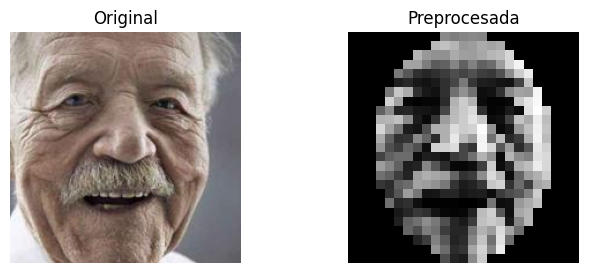

Archivo de ejemplo: 100_0_0_20170112213500903.jpg.chip.jpg


In [57]:
sample_files = sorted(Path(DATASET_DIR).glob("*.jpg"))

if len(sample_files) == 0:
    print("No se encontraron imágenes. Revisa la ruta DATASET_DIR.")
else:
    sample_path = sample_files[0]
    original = cv2.imread(str(sample_path))
    _, processed = preprocess_image_path(sample_path)

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap="gray")
    plt.title("Preprocesada")
    plt.axis("off")
    plt.show()

    print("Archivo de ejemplo:", sample_path.name)


## Construcción del dataset

Ahora construiremos la matriz principal del laboratorio.

### ¿Qué guardaremos?

- `X`: matriz de atributos.
- `y_gender`: etiquetas de género.
- `y_age`: etiquetas de edad.
- `filepaths`: rutas para poder revisar ejemplos después.

Cada fila de `X` corresponderá a un rostro preprocesado.


In [61]:
def build_dataset(root_dir):
    X, y_gender, y_age, filepaths = [], [], [], []

    image_files = sorted(Path(root_dir).glob("*.jpg"))

    for img_path in image_files[:]: #TODO: Solo cargo 100 pero se deben cargar todas
        try:
            age, gender = parse_filename(img_path)
            x_vec, _ = preprocess_image_path(img_path)
            X.append(x_vec)
            y_gender.append(gender)
            y_age.append(age)
            filepaths.append(str(img_path))
        except Exception:
            continue

    X = np.array(X, dtype=np.float32)
    y_gender = np.array(y_gender, dtype=np.int32)
    y_age = np.array(y_age, dtype=np.int32)
    filepaths = np.array(filepaths)

    return X, y_gender, y_age, filepaths


## Ejecutar la carga del dataset

Esta celda construye la matriz completa y muestra un resumen rápido.

Aquí es importante observar:

- cuántas imágenes quedaron finalmente,
- la forma de la matriz,
- si las etiquetas se leen correctamente.


In [62]:
X, y_gender, y_age, filepaths = build_dataset(DATASET_DIR)

print("Forma de X:", X.shape)
print("Forma de y_gender:", y_gender.shape)
print("Forma de y_age:", y_age.shape)

if len(X) > 0:
    print("Primer vector tiene longitud:", len(X[0]))
    print("Primer archivo:", Path(filepaths[0]).name)
    print("Primer género:", y_gender[0], "->", GENDER_MAP.get(int(y_gender[0]), "Desconocido"))
    print("Primera edad:", y_age[0])
else:
    print("No se pudo construir el dataset. Revisa la ruta o el formato de los archivos.")


Forma de X: (573, 625)
Forma de y_gender: (573,)
Forma de y_age: (573,)
Primer vector tiene longitud: 625
Primer archivo: 100_0_0_20170112213500903.jpg.chip.jpg
Primer género: 0 -> Mujer
Primera edad: 100


## Verificación rápida del dataset

Un laboratorio no comienza modelando inmediatamente.  
Antes debemos entender un poco los datos.

En esta sección revisaremos:

- balance de género,
- distribución de edades,
- y una tabla resumen simple.


,filepath,gender,age
0,UTKFace\100_0_0_20170112213500903.jpg.chip.jpg,0,100
1,UTKFace\100_0_0_20170112215240346.jpg.chip.jpg,0,100
2,UTKFace\100_1_0_20170110183726390.jpg.chip.jpg,1,100
3,UTKFace\100_1_0_20170112213001988.jpg.chip.jpg,1,100
4,UTKFace\100_1_0_20170112213303693.jpg.chip.jpg,1,100


Distribución de género:
gender
0    280
1    293
Name: count, dtype: int64


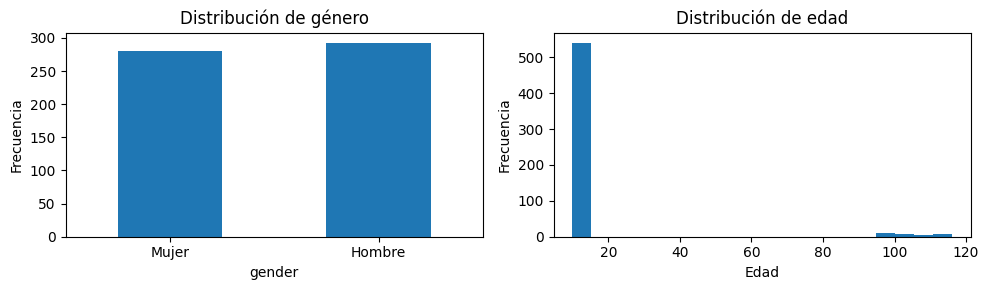

In [64]:
if len(X) > 0:
    df_info = pd.DataFrame({
        "filepath": filepaths,
        "gender": y_gender,
        "age": y_age
    })

    display(df_info.head())

    print("Distribución de género:")
    print(df_info["gender"].value_counts().sort_index())

    plt.figure(figsize=(10, 3))

    plt.subplot(1, 2, 1)
    df_info["gender"].value_counts().sort_index().plot(kind="bar")
    plt.xticks([0, 1], ["Mujer", "Hombre"], rotation=0)
    plt.title("Distribución de género")
    plt.ylabel("Frecuencia")

    plt.subplot(1, 2, 2)
    plt.hist(df_info["age"], bins=20)
    plt.title("Distribución de edad")
    plt.xlabel("Edad")
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()


## Separación entrenamiento y prueba

En aprendizaje automático, el conjunto de prueba debe reservarse para el final.

### En este notebook haremos lo siguiente:

- usar `80%` de los datos para entrenamiento,
- usar `20%` para prueba,
- estratificar por género para mantener la proporción de clases.

La edad se divide usando exactamente los mismos índices.


In [65]:
X_train, X_test, y_gender_train, y_gender_test, y_age_train, y_age_test, fp_train, fp_test =     train_test_split(
        X, y_gender, y_age, filepaths,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_gender
    )

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (458, 625)
Prueba: (115, 625)


## ¿Qué es un pipeline y por qué lo usaremos?

Un **pipeline** es una secuencia ordenada de pasos que transforma los datos y luego aplica un modelo.

En este laboratorio usaremos un pipeline porque queremos que el flujo sea:

- ordenado,
- reproducible,
- consistente entre entrenamiento y validación.

## Pipeline del clasificador de género

El flujo será:

1. recibir vectores de píxeles,
2. aplicar `PCA`,
3. entrenar `GaussianNB`.

Es decir:

`imagen -> preprocesamiento -> vector -> PCA -> GaussianNB -> predicción`


## Implementación completa del clasificador de género

A continuación construiremos el clasificador principal del notebook.

### Estrategia

- usar `Pipeline` para encadenar PCA y GaussianNB,
- usar `GridSearchCV` para probar varios valores de componentes PCA,
- seleccionar la configuración con mejor `F1-score`.

## ¿Por qué F1?

Porque combina `precision` y `recall`, lo que lo vuelve más informativo que usar solo accuracy cuando puede haber desbalance.


In [66]:
pipe_cls = Pipeline([
    ("pca", PCA(whiten=True, random_state=RANDOM_STATE)),
    ("clf", GaussianNB())
])

param_grid_cls = {
    "pca__n_components": PCA_COMPONENTS
}

grid_cls = GridSearchCV(
    estimator=pipe_cls,
    param_grid=param_grid_cls,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_cls.fit(X_train, y_gender_train)

print("Mejor configuración encontrada:")
print(grid_cls.best_params_)
print("Mejor F1 en validación:", grid_cls.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejor configuración encontrada:
{'pca__n_components': 50}
Mejor F1 en validación: 0.6620713518027247


## Evaluación del clasificador de género

Una vez entrenado el mejor pipeline, lo evaluamos en el conjunto de prueba.

### Métricas que calcularemos

- `accuracy`
- `precision`
- `recall`
- `F1-score`
- matriz de confusión

Recuerda que el conjunto de prueba representa datos que el modelo no vio durante el entrenamiento.


In [67]:
best_cls = grid_cls.best_estimator_
y_gender_pred = best_cls.predict(X_test)

acc = accuracy_score(y_gender_test, y_gender_pred)
pre = precision_score(y_gender_test, y_gender_pred)
rec = recall_score(y_gender_test, y_gender_pred)
f1 = f1_score(y_gender_test, y_gender_pred)

print("Accuracy :", round(acc, 4))
print("Precision:", round(pre, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))


Accuracy : 0.7304
Precision: 0.6892
Recall   : 0.8644
F1-score : 0.7669


### Matriz de confusión

La matriz de confusión permite ver más claramente el tipo de error del modelo.

No solo interesa cuántos errores comete, sino también **qué errores** comete.


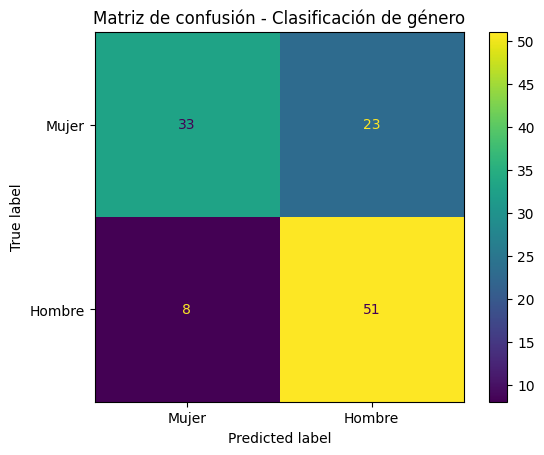

In [68]:
cm = confusion_matrix(y_gender_test, y_gender_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mujer", "Hombre"])
disp.plot()
plt.title("Matriz de confusión - Clasificación de género")
plt.show()


## Revisar algunos ejemplos de predicción

Esta sección es útil para interpretar el comportamiento del clasificador.

La idea es mostrar algunos rostros del conjunto de prueba junto con:

- etiqueta real,
- predicción del modelo.


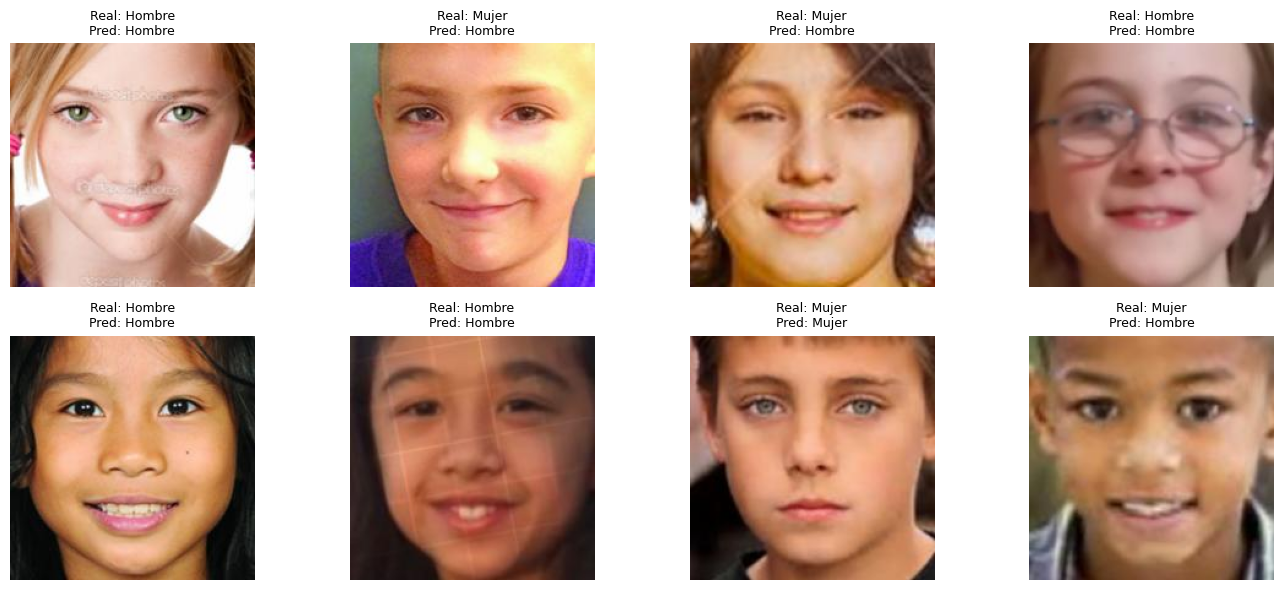

In [70]:
num_examples = min(8, len(X_test))

plt.figure(figsize=(14, 6))
for i in range(num_examples):
    img = cv2.imread(fp_test[i])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    true_label = GENDER_MAP.get(int(y_gender_test[i]), str(y_gender_test[i]))
    pred_label = GENDER_MAP.get(int(y_gender_pred[i]), str(y_gender_pred[i]))

    plt.subplot(2, 4, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Real: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Guardar el mejor clasificador

Guardar el pipeline completo es útil porque luego podremos reutilizarlo en una app o en otro notebook.

Observa que guardamos el **pipeline completo**, no solo el clasificador.  
Eso significa que el PCA también queda almacenado.


In [71]:
joblib.dump(best_cls, "pipeline_genero.pkl")
print("Pipeline guardado como pipeline_genero.pkl")


Pipeline guardado como pipeline_genero.pkl


## Regresión de edad: sección guiada

Hasta aquí implementamos completamente la parte de clasificación de género.

Ahora mostraremos **solo lo suficiente para encaminar** la tarea de regresión de edad.

## Idea general

Usaremos exactamente el mismo flujo base:

1. vectores de píxeles ya preprocesados,
2. PCA,
3. Regresión Lineal.

Es decir:

`imagen -> preprocesamiento -> vector -> PCA -> LinearRegression -> edad estimada`

## Mensaje importante

La estimación de edad suele ser un problema más difícil que la clasificación binaria de género.  
Por eso aquí la trataremos como una línea base inicial.


## Código guía para la regresión de edad

En esta sección dejamos una implementación sencilla para que el estudiante la ejecute, observe resultados y luego la mejore.

Las métricas sugeridas son:

- `MAE`
- `RMSE`
- `R2`


In [72]:
def build_age_dataset(root_dir):
    X_age, y_age, filepaths_age = [], [], []

    image_files = sorted(Path(root_dir).glob("*.jpg"))

    for img_path in image_files:
        try:
            age, _ = parse_filename(img_path)
            x_vec, _ = preprocess_image_path(img_path)
            X_age.append(x_vec)
            y_age.append(age)
            filepaths_age.append(str(img_path))
        except Exception:
            continue

    X_age = np.array(X_age, dtype=np.float32)
    y_age = np.array(y_age, dtype=np.int32)
    filepaths_age = np.array(filepaths_age)

    return X_age, y_age, filepaths_age


X_age_full, y_age_full, filepaths_age = build_age_dataset(DATASET_DIR)

X_age_train, X_age_test, y_age_train, y_age_test, fp_age_train, fp_age_test = train_test_split(
    X_age_full, y_age_full, filepaths_age,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Entrenamiento edad:", X_age_train.shape)
print("Prueba edad:", X_age_test.shape)

pipe_reg = Pipeline([
    ("pca", PCA(whiten=True, random_state=RANDOM_STATE)),
    ("reg", LinearRegression())
])

param_grid_reg = {
    "pca__n_components": PCA_COMPONENTS
}

grid_reg = GridSearchCV(
    estimator=pipe_reg,
    param_grid=param_grid_reg,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_reg.fit(X_age_train, y_age_train)

best_reg = grid_reg.best_estimator_
y_age_pred = best_reg.predict(X_age_test)

mae = mean_absolute_error(y_age_test, y_age_pred)
rmse = np.sqrt(mean_squared_error(y_age_test, y_age_pred))
r2 = r2_score(y_age_test, y_age_pred)

print("Mejor configuración:", grid_reg.best_params_)
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2  :", round(r2, 4))

joblib.dump(best_reg, "pipeline_edad.pkl")
print("Pipeline guardado como pipeline_edad.pkl")


Entrenamiento edad: (458, 625)
Prueba edad: (115, 625)
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejor configuración: {'pca__n_components': 30}
MAE : 12.1764
RMSE: 18.9612
R2  : 0.2647
Pipeline guardado como pipeline_edad.pkl


## ¿Qué debe hacer el estudiante en la parte de regresión?

Aquí no desarrollaremos una exploración extensa, porque la idea es dejar el camino listo.

### Sugerencias para continuar

1. Probar distintos tamaños de imagen.
2. Comparar con y sin máscara oval.
3. Comparar con más o menos componentes PCA.
4. Graficar edad real versus edad predicha.
5. Discutir por qué una relación lineal puede ser insuficiente.

La meta aquí no es cerrar el problema, sino **encaminarlo correctamente**.


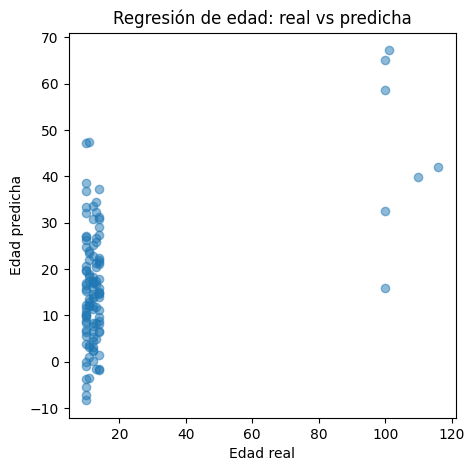

In [46]:
# Ejemplo opcional: gráfico simple edad real vs edad predicha
plt.figure(figsize=(5, 5))
plt.scatter(y_age_test, y_age_pred, alpha=0.5)
plt.xlabel("Edad real")
plt.ylabel("Edad predicha")
plt.title("Regresión de edad: real vs predicha")
plt.show()


## Resultado esperado final del laboratorio

El producto final esperado no es solo un modelo entrenado.

La meta del laboratorio es llegar a una aplicación en **Streamlit** donde el usuario pueda:

1. subir una fotografía,
2. detectar una o más caras,
3. recortar cada rostro,
4. aplicar el mismo pipeline,
5. mostrar para cada rostro:
   - clasificación de género,
   - edad estimada.

## Relación con CRISP-DM

Esta etapa corresponde a **Deployment**.


## Esqueleto básico para una futura app en Streamlit

La siguiente celda no está pensada para ejecutarse en este notebook como producto final, sino para mostrar la idea general del despliegue.


In [21]:
streamlit_example = r'''
import cv2
import joblib
import numpy as np
import streamlit as st

st.title("Clasificación de género y regresión de edad")

clf_pipeline = joblib.load("pipeline_genero.pkl")
reg_pipeline = joblib.load("pipeline_edad.pkl")

uploaded_file = st.file_uploader("Sube una imagen", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    faces = detector.detectMultiScale(image, scaleFactor=1.1, minNeighbors=5)

    for (x, y, w, h) in faces:
        face = image[y:y+h, x:x+w]

        # Aquí debes reutilizar exactamente el mismo preprocesamiento del laboratorio
        x_vec, _ = preprocess_face_array(face)

        pred_gender = clf_pipeline.predict([x_vec])[0]
        pred_age = reg_pipeline.predict([x_vec])[0]

        label = f"Genero: {pred_gender} | Edad: {pred_age:.1f}"

        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(image, label, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    st.image(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), caption="Resultado")
'''
print(streamlit_example)



import cv2
import joblib
import numpy as np
import streamlit as st

st.title("Clasificación de género y regresión de edad")

clf_pipeline = joblib.load("pipeline_genero.pkl")
reg_pipeline = joblib.load("pipeline_edad.pkl")

uploaded_file = st.file_uploader("Sube una imagen", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    faces = detector.detectMultiScale(image, scaleFactor=1.1, minNeighbors=5)

    for (x, y, w, h) in faces:
        face = image[y:y+h, x:x+w]

        # Aquí debes reutilizar exactamente el mismo preprocesamiento del laboratorio
        x_vec, _ = preprocess_face_array(face)

        pred_gender = clf_pipeline.predict([x_vec])[0]
        pred_age = reg_pipeline.predict([x_vec])[0]

        label = f"Genero: {

## Preguntas guía para interpretar los resultados

1. ¿Qué ventajas tuvo usar un pipeline en este laboratorio?
2. ¿Qué efecto tuvo PCA sobre el clasificador de género?
3. ¿Cuál fue el mejor número de componentes PCA?
4. ¿Qué errores aparecen en la matriz de confusión?
5. ¿La regresión de edad parece más difícil que la clasificación de género? ¿Por qué?
6. ¿Qué etapa de CRISP-DM representa cada parte del notebook?
7. ¿Qué desafíos aparecen cuando se pasa del experimento en notebook a una app en Streamlit?


## Cierre

En este notebook trabajamos una línea base completa para clasificación de género y una guía inicial para regresión de edad.

Lo importante no es solo entrenar modelos, sino entender el flujo completo:

- problema,
- datos,
- preparación,
- modelado,
- evaluación,
- despliegue.

Ese es precisamente el espíritu de **CRISP-DM** y también la razón por la que este laboratorio termina proyectándose hacia una aplicación real.


In [44]:
# Carga completa separada para la regresión de edad.
def build_age_dataset(root_dir):
    X_age, y_age, filepaths_age = [], [], []

    image_files = sorted(Path(root_dir).glob("*.jpg"))

    for img_path in image_files:
        try:
            age, _ = parse_filename(img_path)
            x_vec, _ = preprocess_image_path(img_path)
            X_age.append(x_vec)
            y_age.append(age)
            filepaths_age.append(str(img_path))
        except Exception:
            continue

    X_age = np.array(X_age, dtype=np.float32)
    y_age = np.array(y_age, dtype=np.int32)
    filepaths_age = np.array(filepaths_age)

    print(f"Dataset de edad cargado: {len(X_age)} muestras")
    return X_age, y_age, filepaths_age